# PowerLens — 03. EDA Bivariée & Patterns Temporels

> **KaynorData** · Descriptive Analytics · Energy Domain

---

## Objectif

Analyser les **relations entre variables** et les **patterns temporels** :
- Corrélations entre variables numériques
- Consommation par heure, jour de semaine, mois
- Heatmap heure × jour
- Comparaison semaine vs week-end


## 0. Imports & Chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

df = pd.read_parquet('../data/processed/powerlens_clean.parquet')
print(f'Dataset chargé : {df.shape[0]:,} lignes')

Dataset chargé : 2,075,259 lignes


## 1. Matrice de corrélation

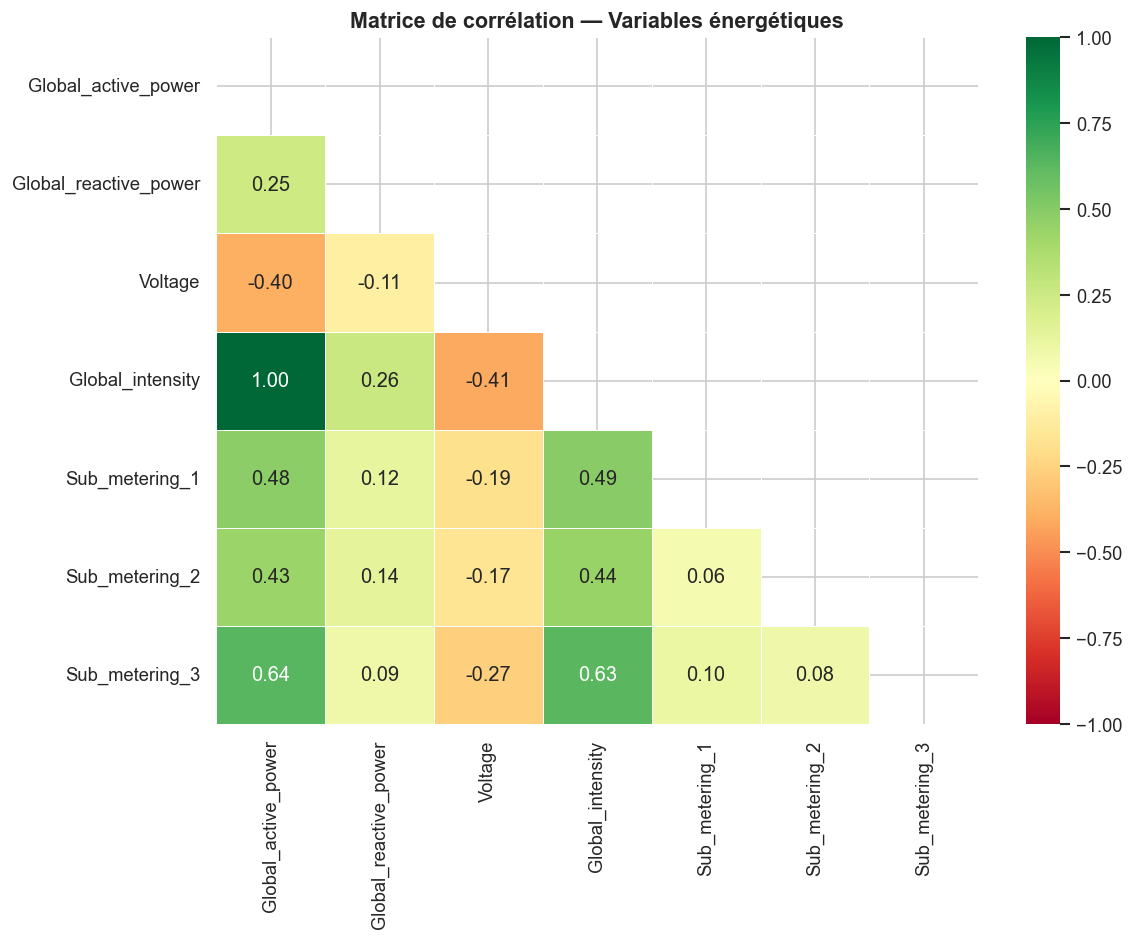

In [2]:
numeric_cols = [
    'Global_active_power', 'Global_reactive_power',
    'Voltage', 'Global_intensity',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Masque triangle supérieur

sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    mask=mask,
    center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Matrice de corrélation — Variables énergétiques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/03_correlation_matrix.png', dpi=150)
plt.show()

## 2. Consommation moyenne par heure de la journée

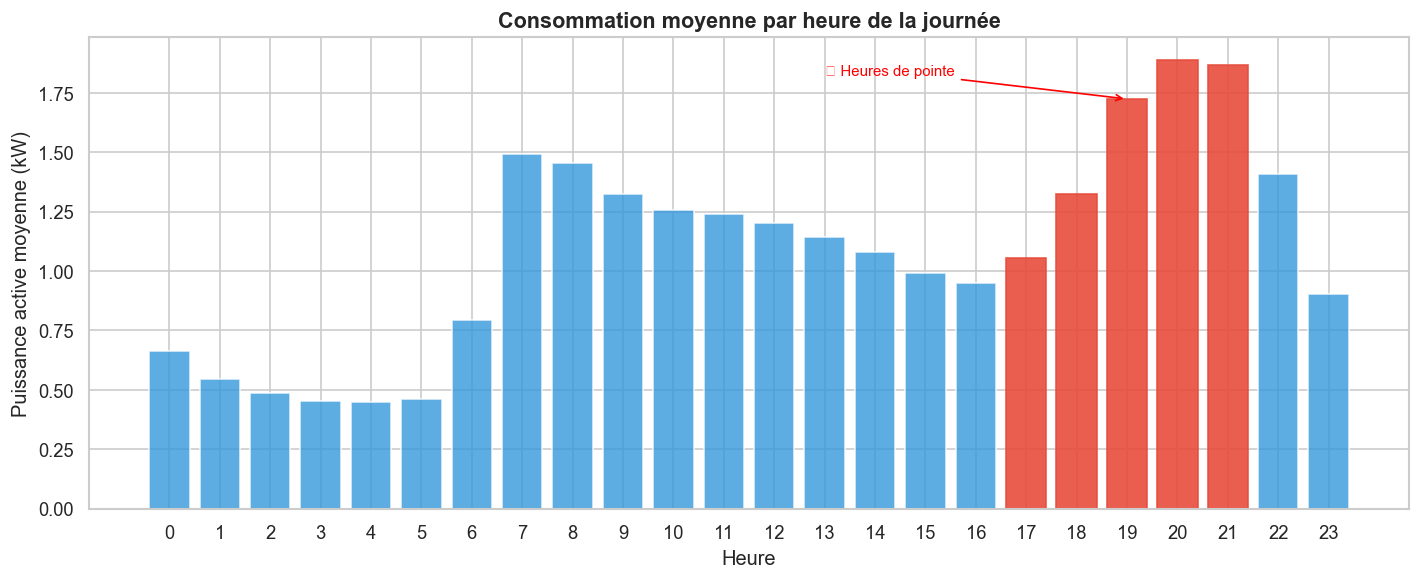

In [3]:
hourly_avg = df.groupby('hour')['Global_active_power'].mean()

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(hourly_avg.index, hourly_avg.values, color='#3498db', alpha=0.8, edgecolor='white')

# Colorer les heures de pointe (17h-21h)
peak_hours = [17, 18, 19, 20, 21]
for bar, hour in zip(bars, hourly_avg.index):
    if hour in peak_hours:
        bar.set_color('#e74c3c')
        bar.set_alpha(0.9)

ax.set_title('Consommation moyenne par heure de la journée', fontsize=13, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Puissance active moyenne (kW)')
ax.set_xticks(range(0, 24))

# Annotation heures de pointe
ax.annotate('⚡ Heures de pointe', xy=(19, hourly_avg[19]), xytext=(13, hourly_avg[19] + 0.1),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/03_consumption_by_hour.png', dpi=150)
plt.show()

## 3. Consommation par jour de la semaine

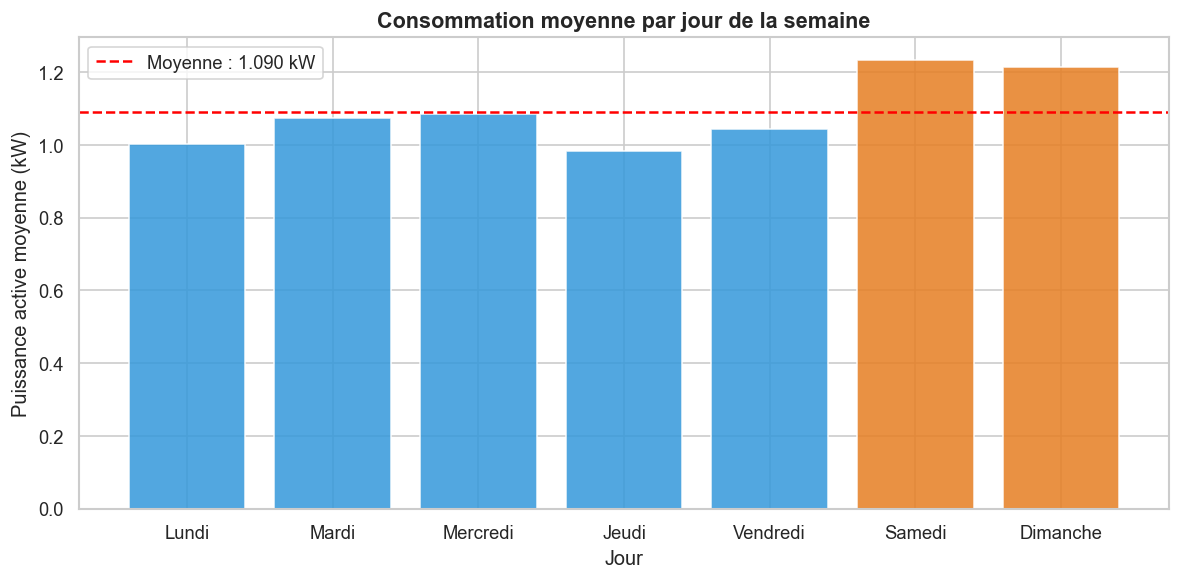

In [4]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_labels = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']

daily_avg = df.groupby('day_name')['Global_active_power'].mean().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
colors_day = ['#3498db'] * 5 + ['#e67e22', '#e67e22']  # Week-end en orange

ax.bar(day_labels, daily_avg.values, color=colors_day, alpha=0.85, edgecolor='white')
ax.axhline(daily_avg.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Moyenne : {daily_avg.mean():.3f} kW')

ax.set_title('Consommation moyenne par jour de la semaine', fontsize=13, fontweight='bold')
ax.set_xlabel('Jour')
ax.set_ylabel('Puissance active moyenne (kW)')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/03_consumption_by_day.png', dpi=150)
plt.show()

## 4. Consommation par mois — Saisonnalité

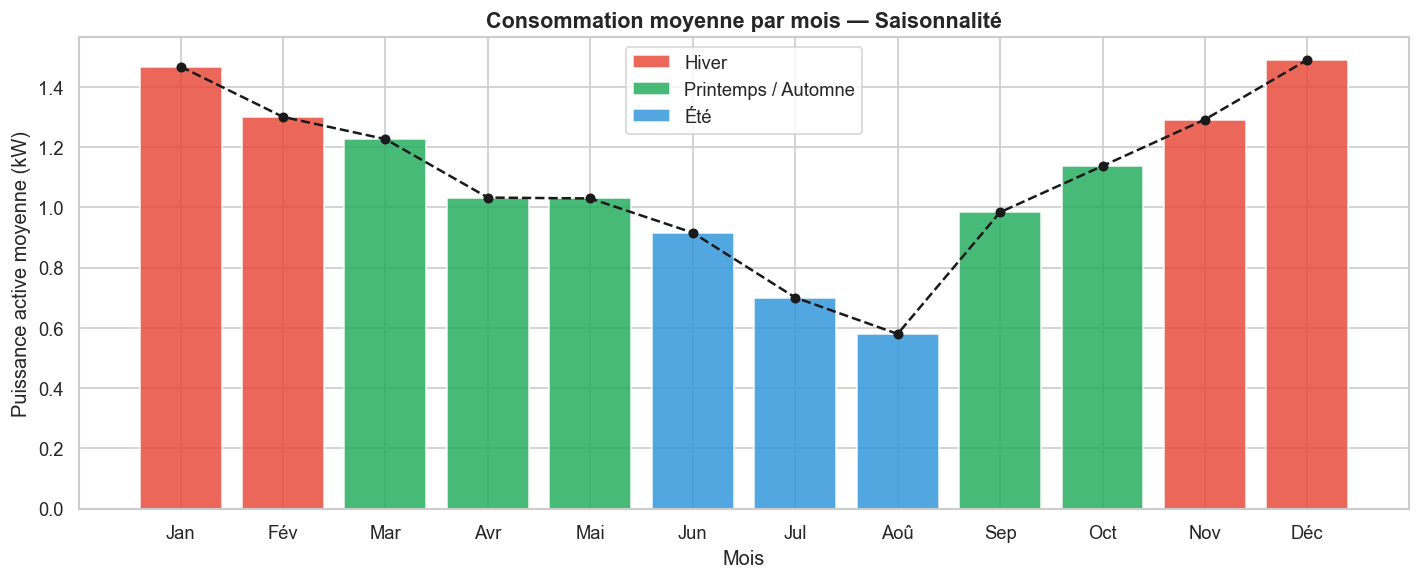

In [5]:
monthly_avg = df.groupby('month')['Global_active_power'].mean()
month_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

fig, ax = plt.subplots(figsize=(12, 5))

# Couleur selon saison (hiver = rouge, été = bleu)
season_colors = ['#e74c3c','#e74c3c','#27ae60','#27ae60','#27ae60',
                 '#3498db','#3498db','#3498db','#27ae60','#27ae60','#e74c3c','#e74c3c']

ax.bar(month_labels, monthly_avg.values, color=season_colors, alpha=0.85, edgecolor='white')
ax.plot(month_labels, monthly_avg.values, 'ko--', linewidth=1.5, markersize=5)

ax.set_title('Consommation moyenne par mois — Saisonnalité', fontsize=13, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('Puissance active moyenne (kW)')

# Légende saisons
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', alpha=0.85, label='Hiver'),
    Patch(facecolor='#27ae60', alpha=0.85, label='Printemps / Automne'),
    Patch(facecolor='#3498db', alpha=0.85, label='Été')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('../reports/figures/03_consumption_by_month.png', dpi=150)
plt.show()

## 5. Heatmap — Heure × Jour de semaine

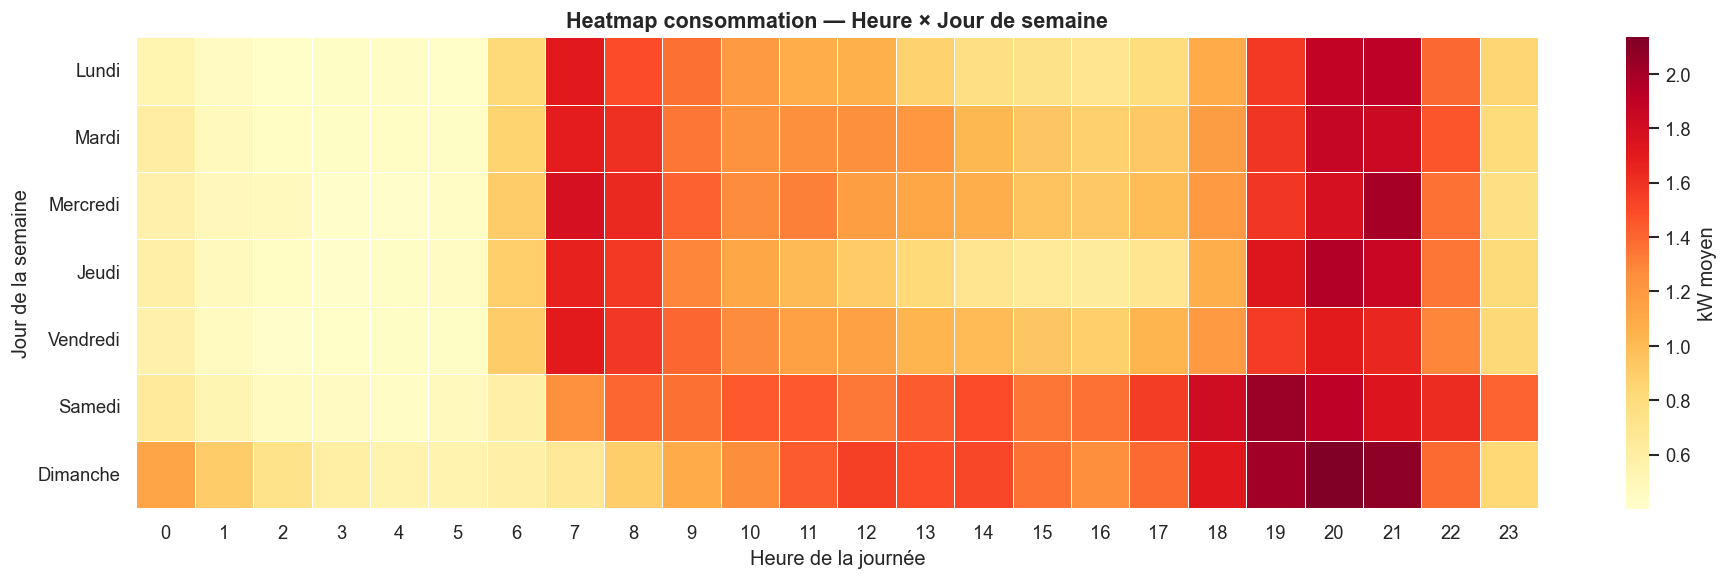

In [6]:
pivot = df.groupby(['day_of_week', 'hour'])['Global_active_power'].mean().unstack()
pivot.index = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.3,
    ax=ax,
    cbar_kws={'label': 'kW moyen'}
)

ax.set_title('Heatmap consommation — Heure × Jour de semaine', fontsize=13, fontweight='bold')
ax.set_xlabel('Heure de la journée')
ax.set_ylabel('Jour de la semaine')

plt.tight_layout()
plt.savefig('../reports/figures/03_heatmap_hour_day.png', dpi=150)
plt.show()

## 6. Semaine vs Week-end — Comparaison des profils horaires

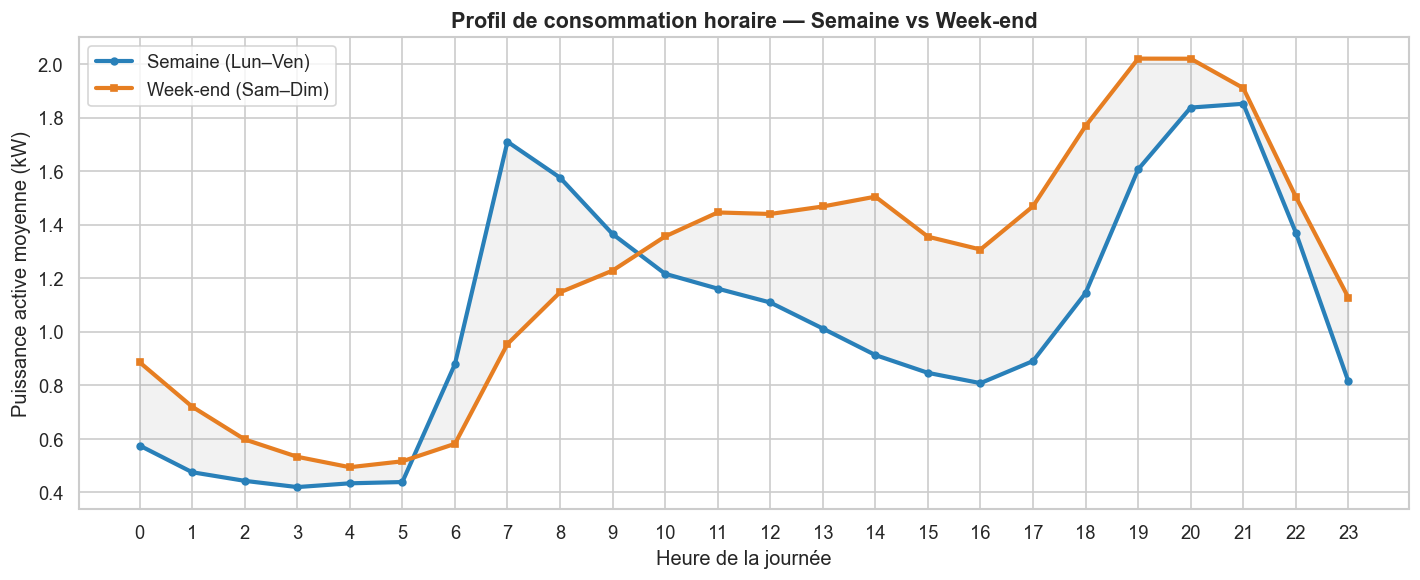

In [7]:
weekday_profile = df[df['is_weekend'] == 0].groupby('hour')['Global_active_power'].mean()
weekend_profile = df[df['is_weekend'] == 1].groupby('hour')['Global_active_power'].mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(weekday_profile.index, weekday_profile.values, color='#2980b9', linewidth=2.5, marker='o', markersize=4, label='Semaine (Lun–Ven)')
ax.plot(weekend_profile.index, weekend_profile.values, color='#e67e22', linewidth=2.5, marker='s', markersize=4, label='Week-end (Sam–Dim)')

ax.fill_between(weekday_profile.index, weekday_profile.values, weekend_profile.values, alpha=0.1, color='gray')

ax.set_title('Profil de consommation horaire — Semaine vs Week-end', fontsize=13, fontweight='bold')
ax.set_xlabel('Heure de la journée')
ax.set_ylabel('Puissance active moyenne (kW)')
ax.set_xticks(range(0, 24))
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/03_weekday_vs_weekend.png', dpi=150)
plt.show()

## 7. Scatter plot — Puissance active vs Intensité

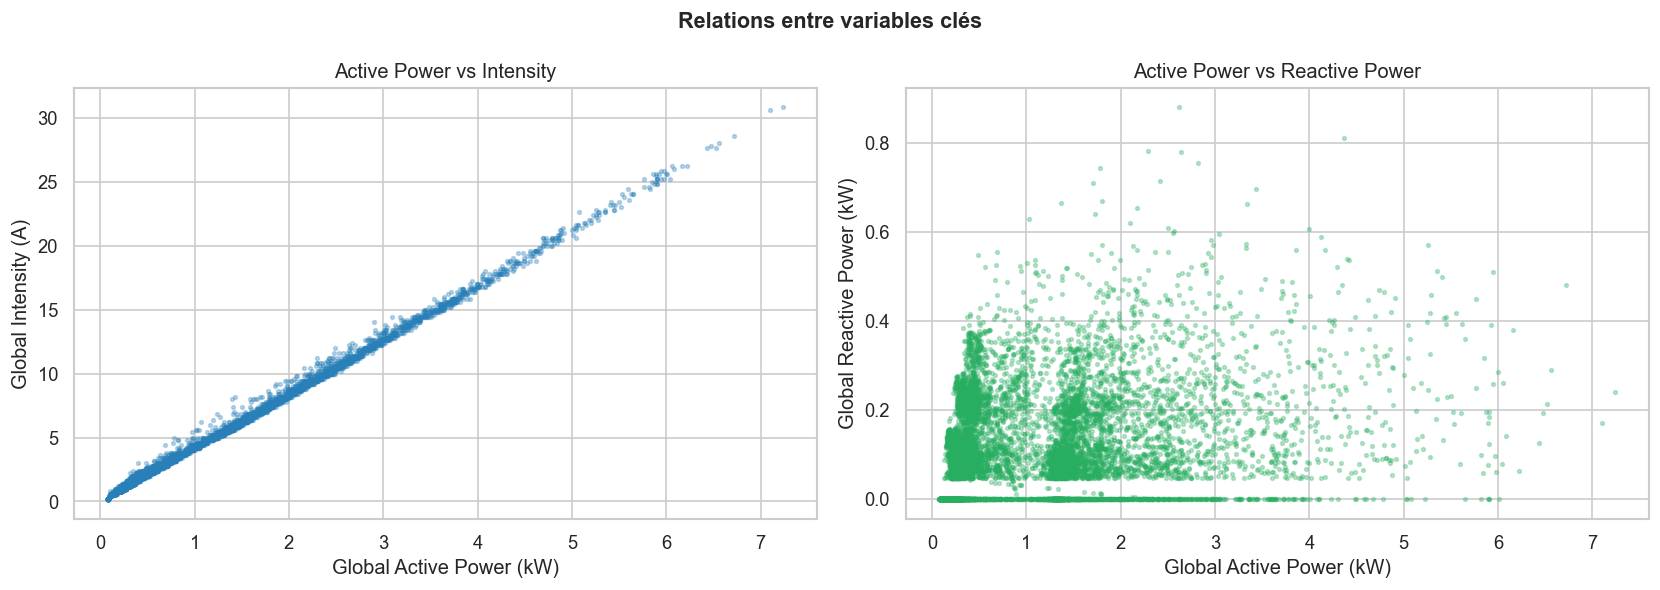

In [8]:
# Échantillon pour la lisibilité
sample = df.sample(n=10000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Relations entre variables clés', fontsize=13, fontweight='bold')

# Active Power vs Intensity
axes[0].scatter(sample['Global_active_power'], sample['Global_intensity'],
                alpha=0.3, s=5, color='#2980b9')
axes[0].set_xlabel('Global Active Power (kW)')
axes[0].set_ylabel('Global Intensity (A)')
axes[0].set_title('Active Power vs Intensity')

# Active Power vs Reactive Power
axes[1].scatter(sample['Global_active_power'], sample['Global_reactive_power'],
                alpha=0.3, s=5, color='#27ae60')
axes[1].set_xlabel('Global Active Power (kW)')
axes[1].set_ylabel('Global Reactive Power (kW)')
axes[1].set_title('Active Power vs Reactive Power')

plt.tight_layout()
plt.savefig('../reports/figures/03_scatter_relationships.png', dpi=150)
plt.show()

## 8. Résumé des observations

| Pattern | Observation |
|---------|-------------|
| **Heures de pointe** | 17h–21h — consommation max en soirée |
| **Heures creuses** | 1h–5h — consommation minimale |
| **Week-end vs Semaine** | Le week-end montre un pic matinal décalé (10h vs 7h en semaine) |
| **Saisonnalité** | Hiver (Jan–Fév, Déc) = consommation ~2× supérieure à l'été |
| **Corrélation forte** | Global_active_power ↔ Global_intensity (r ≈ 1.0) |
| **Corrélation faible** | Voltage légèrement négatif avec la puissance active |

---
**Prochain notebook :** `04_visualisations.ipynb` — Dashboard final & export des figures clés